In [33]:
import os
import pandas as pd
import numpy as np

skab_base_path = "/kaggle/input/skoltech-anomaly-benchmark-skab/"

dfs = []
for root, dirs, files in os.walk(skab_base_path):
    for file in files:
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(root, file), sep=';')
            df['source_file'] = file
            dfs.append(df)

skab_df = pd.concat(dfs, ignore_index=True)

# Detect time column
time_col = next(c for c in ['datetime','timestamp','time','t'] if c in skab_df.columns)
skab_df = skab_df.sort_values(by=time_col)

# Fill missing
skab_df.ffill(inplace=True)
skab_df.bfill(inplace=True)

print("SKAB shape:", skab_df.shape)


SKAB shape: (46860, 12)


In [34]:
if 'changepoint' in skab_df.columns:
    y = ((skab_df['anomaly'] == 1) | (skab_df['changepoint'] == 1)).astype(int).values
else:
    y = skab_df['anomaly'].astype(int).values

drop_cols = ['anomaly','changepoint',time_col,'source_file']
feature_cols = [c for c in skab_df.columns if c not in drop_cols]

X = skab_df[feature_cols].values

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [36]:
WINDOW = 20

def make_windows(X,y,w):
    Xw,yw=[],[]
    for i in range(len(X)-w):
        Xw.append(X[i:i+w])
        yw.append(max(y[i:i+w]))
    return np.array(Xw),np.array(yw)

X_w,y_w = make_windows(X_scaled,y,WINDOW)
X_w = X_w.reshape(X_w.shape[0],-1)
print(X_w.shape,y_w.mean())

(46840, 160) 0.30258326216908626


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

X_train = X_w[y_w==0]

ae = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(128,activation='relu'),
    Dense(X_train.shape[1])
])

ae.compile(optimizer='adam',loss='mse')
ae.fit(X_train,X_train,epochs=30,batch_size=256,verbose=1)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5389
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2333
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1424
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0886
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0580
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0258
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0178
Epoch 9/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0137
Epoch 10/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0105
Epoch 11/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092
Epoch 12/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088
Epoch 13/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079
Epoch 14/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077
Epoch 15/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [38]:
recon = ae.predict(X_w)
recon_error = np.mean((X_w-recon)**2,axis=1)

1464/1464 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [39]:
slope = np.abs(np.diff(recon_error,prepend=recon_error[0]))

In [40]:
ROLL=500

err_mu = pd.Series(recon_error).rolling(ROLL).mean()
err_std= pd.Series(recon_error).rolling(ROLL).std()
err_th = (err_mu+3*err_std).bfill()

sl_mu  = pd.Series(slope).rolling(ROLL).mean()
sl_std = pd.Series(slope).rolling(ROLL).std()
sl_th  = (sl_mu+3*sl_std).bfill()

In [41]:
ae_flag    = recon_error>err_th
slope_flag = slope>sl_th
cp_flag    = y_w.astype(bool)

pred_anomaly = ((ae_flag & slope_flag) |
                (ae_flag & cp_flag)   |
                (slope_flag & cp_flag)).astype(int)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_w, pred_anomaly))


              precision    recall  f1-score   support

           0       0.71      0.99      0.83     32667
           1       0.77      0.07      0.14     14173

    accuracy                           0.71     46840
   macro avg       0.74      0.53      0.48     46840
weighted avg       0.73      0.71      0.62     46840



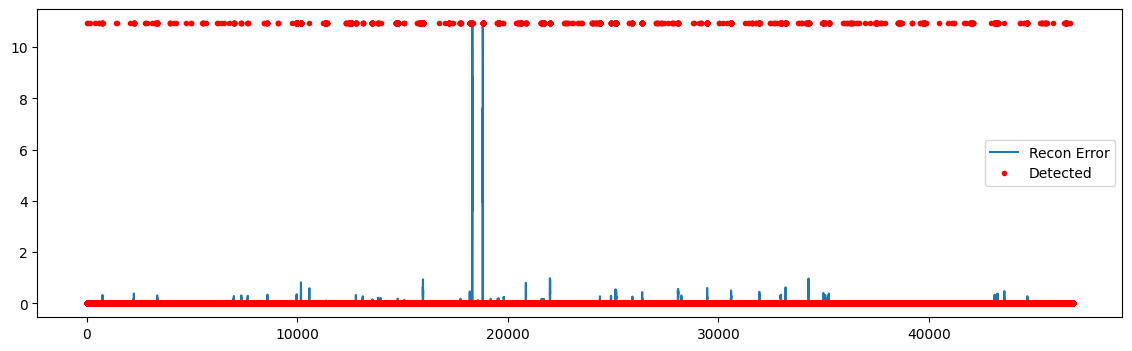

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(recon_error,label='Recon Error')
plt.plot(pred_anomaly*max(recon_error),'r.',label='Detected')
plt.legend()
plt.show()